# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns",None)

# 2. EDA

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
df.drop("id", axis=1, inplace=True)

In [5]:
df.isnull().sum()

Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap          

In [7]:
df.describe()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


# 3. Graphs

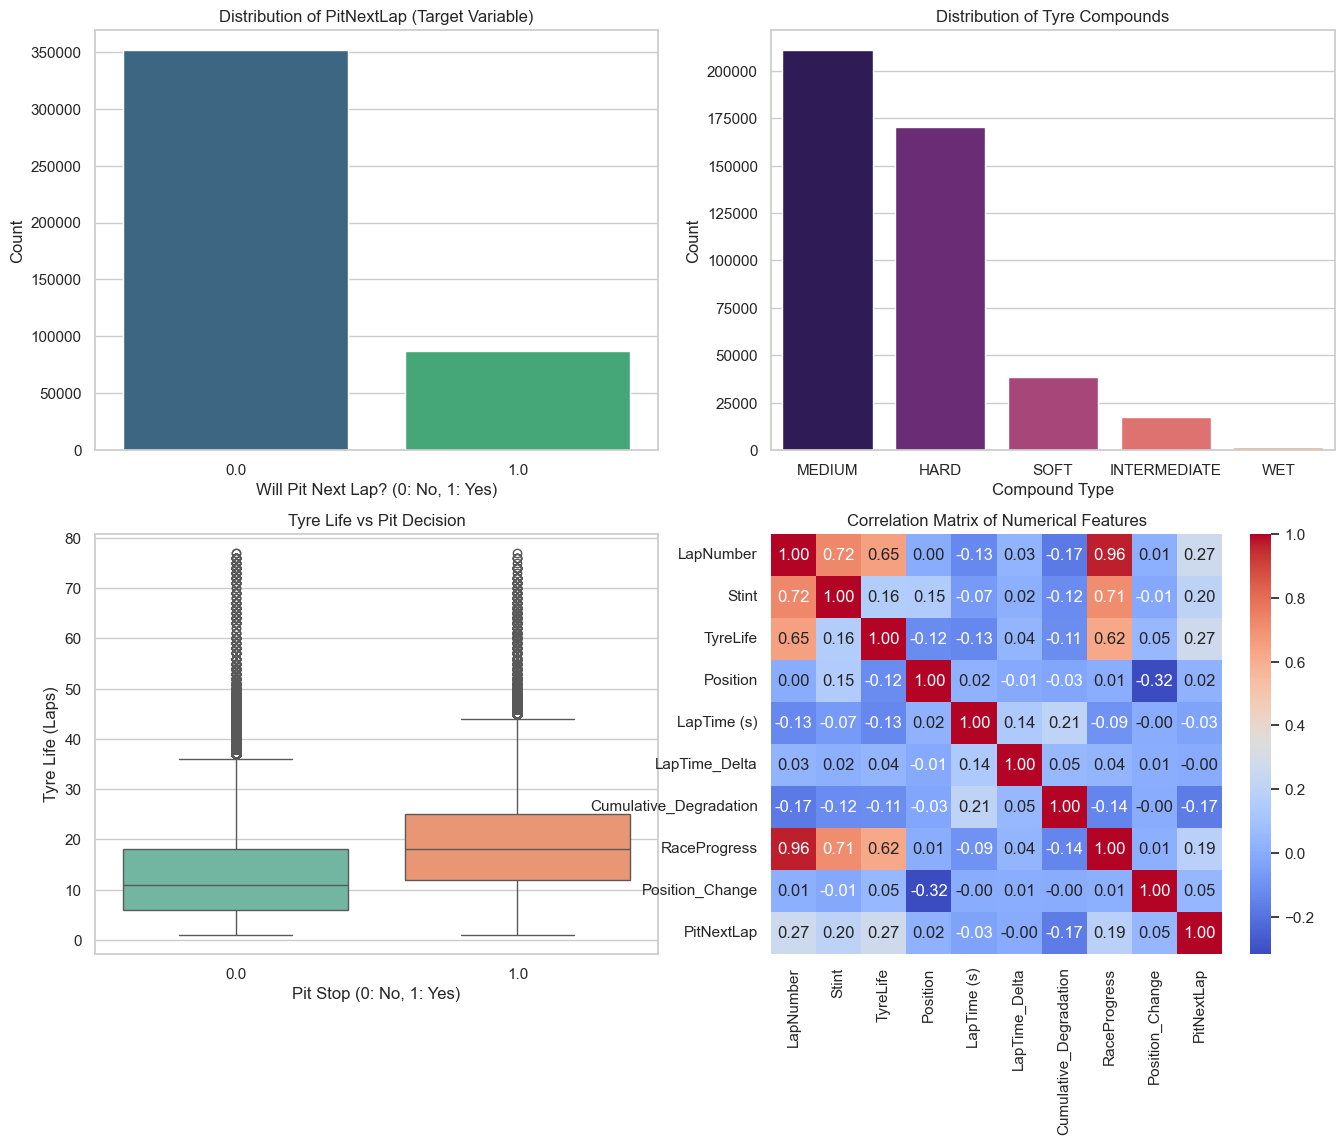

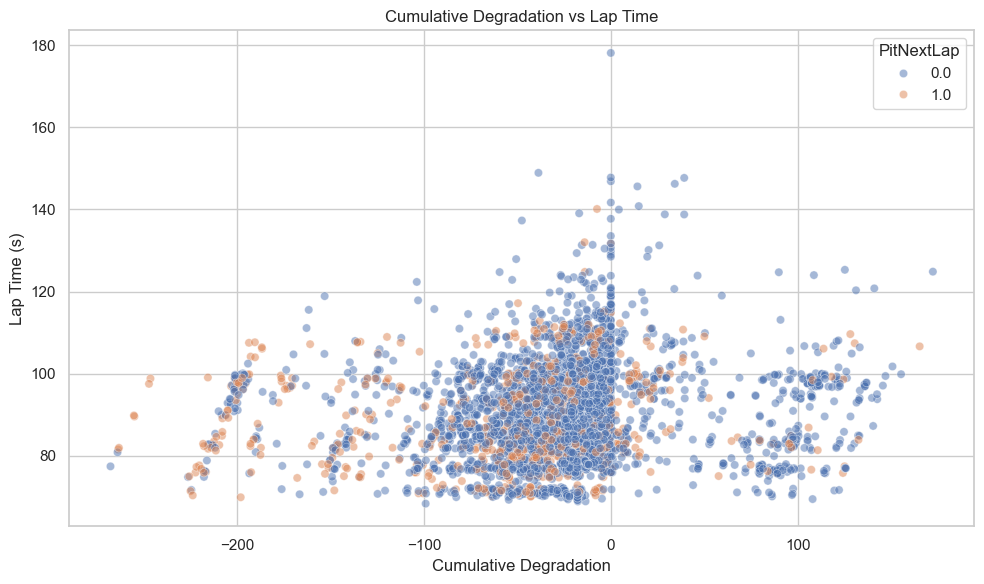

In [8]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of PitNextLap (Target Variable)
sns.countplot(
    data=df,
    x='PitNextLap',
    ax=axes[0, 0],
    palette='viridis'
)

axes[0, 0].set_title('Distribution of PitNextLap (Target Variable)')
axes[0, 0].set_xlabel('Will Pit Next Lap? (0: No, 1: Yes)')
axes[0, 0].set_ylabel('Count')

# 2. Distribution of Tyre Compounds
compound_order = df['Compound'].value_counts().index

sns.countplot(
    data=df,
    x='Compound',
    order=compound_order,
    ax=axes[0, 1],
    palette='magma'
)

axes[0, 1].set_title('Distribution of Tyre Compounds')
axes[0, 1].set_xlabel('Compound Type')
axes[0, 1].set_ylabel('Count')

# 3. TyreLife vs PitNextLap
sns.boxplot(
    data=df,
    x='PitNextLap',
    y='TyreLife',
    ax=axes[1, 0],
    palette='Set2'
)

axes[1, 0].set_title('Tyre Life vs Pit Decision')
axes[1, 0].set_xlabel('Pit Stop (0: No, 1: Yes)')
axes[1, 0].set_ylabel('Tyre Life (Laps)')

# 4. Correlation Heatmap
numeric_cols = [
    'LapNumber',
    'Stint',
    'TyreLife',
    'Position',
    'LapTime (s)',
    'LapTime_Delta',
    'Cumulative_Degradation',
    'RaceProgress',
    'Position_Change',
    'PitNextLap'
]

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    ax=axes[1, 1],
    cbar=True
)

axes[1, 1].set_title('Correlation Matrix of Numerical Features')

# Scatterplot
plt.figure(figsize=(10, 6))

df_sample = df.sample(
    n=min(5000, len(df)),
    random_state=42
)

sns.scatterplot(
    data=df_sample,
    x='Cumulative_Degradation',
    y='LapTime (s)',
    hue='PitNextLap',
    alpha=0.5
)

plt.title('Cumulative Degradation vs Lap Time')
plt.xlabel('Cumulative Degradation')
plt.ylabel('Lap Time (s)')

plt.tight_layout()
plt.show()

## 3.1 Finding Ouliers & Checking Skewness and Kurtosis

In [9]:
numeric_cols = [
    "LapNumber",
    "Stint",
    "TyreLife",
    "Position",
    "LapTime (s)",
    "LapTime_Delta",
    "Cumulative_Degradation",
    "RaceProgress",
    "Position_Change"
]

def find_outliers_iqr(df, threshold=1.5):
    outlier_summary = {}

    numeric_cols = df.select_dtypes(
        include=["int32", "float32", "float64", "int64"]
    ).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        # IQR
        IQR = Q3 - Q1

        # Bounds
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        # Outliers
        outliers = df[
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        ]

        # Skewness
        skewness = df[col].skew()

        # Kurtosis
        kurtosis = df[col].kurt()

        outlier_summary[col] = {
            "outlier_count": outliers.shape[0],
            "outlier_percentage": 100 * outliers.shape[0] / df.shape[0],
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "skewness": skewness,
            "kurtosis": kurtosis
        }

    return pd.DataFrame(outlier_summary)

find_outliers_iqr(df[numeric_cols])

,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
outlier_count,16.000000,24078.000000,5711.000000,0.000000,5905.000000,58900.000000,49869.000000,0.000000,61180.000000
outlier_percentage,0.003643,5.482989,1.300496,0.000000,1.344674,13.412579,11.356060,0.000000,13.931776
lower_bound,-31.500000,-0.500000,-15.000000,-8.500000,58.846000,-22.382500,-107.117125,-0.445062,-5.500000
upper_bound,76.500000,3.500000,41.000000,27.500000,122.246000,13.613500,54.351875,1.088090,6.500000
skewness,0.645965,1.185479,1.032448,0.070098,80.334328,-40.855061,3.191501,0.699950,-0.092714
kurtosis,-0.567197,1.269834,1.436690,-1.099361,9679.350640,2674.619364,156.352463,-0.514614,1.805532


In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print()

Driver
['D109' 'D086' 'ZON' 'SPE' 'D019' 'D012' 'D104' 'D082' 'BEL' 'YAM' 'MAS'
 'D010' 'D063' 'D196' 'D132' 'D047' 'PRO' 'D066' 'DRA' 'PEA' 'HAD' 'HUL'
 'COU' 'D036' 'D205' 'BER' 'VIL' 'GUT' 'TUR' 'D089' 'D055' 'D189' 'D071'
 'DAM' 'D144' 'D384' 'D263' 'D117' 'D120' 'D054' 'D184' 'D214' 'IDE'
 'D216' 'D101' 'D160' 'WIL' 'CAR' 'D251' 'D106' 'D083' 'WAR' 'D065' 'MIN'
 'D293' 'BIA' 'D125' 'D073' 'ALE' 'D007' 'D009' 'D202' 'NOR' 'FRE' 'D057'
 'D177' 'D049' 'ALG' 'SUT' 'D312' 'D159' 'D219' 'ROS' 'D166' 'D218' 'D045'
 'D197' 'GIO' 'DIR' 'D138' 'WEB' 'D070' 'D097' 'LEC' 'D050' 'D369' 'HYD'
 'D355' 'D032' 'D292' 'BEA' 'D001' 'D232' 'D211' 'DIN' 'D157' 'NAK' 'TAY'
 'STR' 'D325' 'D028' 'RIC' 'ZHO' 'GAS' 'D041' 'D014' 'D283' 'WUR' 'D061'
 'D281' 'D046' 'TSU' 'D170' 'D122' 'D210' 'D191' 'D074' 'SHA' 'D128'
 'D254' 'D285' 'CAN' 'FUJ' 'D152' 'D038' 'FER' 'FON' 'ROB' 'D002' 'D020'
 'D224' 'D244' 'MAR' 'D096' 'D116' 'D081' 'SEN' 'D064' 'COL' 'D194' 'D035'
 'SAT' 'SCH' 'D053' 'TAK' 'ARN' 'D023' 'D148'

In [ ]:
cols_to_ohe = ["Compound","Race", "Year"]

cols_to_scale = [
    "LapNumber",
    "Stint",
    "TyreLife",
    "Position",
    "LapTime (s)",
    "LapTime_Delta",
    "Cumulative_Degradation",
    "RaceProgress",
    "Position_Change"
]

# 4. Define Dependent & Independent Variables and Train-Test Split

In [12]:
X = df.drop(["PitNextLap","Driver"], axis=1)
y = df["PitNextLap"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [14]:
preprocessor = ColumnTransformer(transformers=[
    ("ohe", OneHotEncoder(handle_unknown="ignore",sparse_output=False), cols_to_ohe),
    ("scale", StandardScaler(), cols_to_scale)
], remainder="passthrough")

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

names = preprocessor.get_feature_names_out()

X_train_transformed = pd.DataFrame(X_train_transformed, columns=names, index=X_train.index)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=names, index=X_test.index)

In [15]:
X_train_transformed.head()

,ohe__Compound_HARD,ohe__Compound_INTERMEDIATE,ohe__Compound_MEDIUM,ohe__Compound_SOFT,ohe__Compound_WET,ohe__Race_Abu Dhabi Grand Prix,ohe__Race_Australian Grand Prix,ohe__Race_Austrian Grand Prix,ohe__Race_Azerbaijan Grand Prix,ohe__Race_Bahrain Grand Prix,ohe__Race_Belgian Grand Prix,ohe__Race_British Grand Prix,ohe__Race_Canadian Grand Prix,ohe__Race_Chinese Grand Prix,ohe__Race_Dutch Grand Prix,ohe__Race_Emilia Romagna Grand Prix,ohe__Race_French Grand Prix,ohe__Race_Hungarian Grand Prix,ohe__Race_Italian Grand Prix,ohe__Race_Japanese Grand Prix,ohe__Race_Las Vegas Grand Prix,ohe__Race_Mexico City Grand Prix,ohe__Race_Miami Grand Prix,ohe__Race_Monaco Grand Prix,ohe__Race_Pre-Season Testing,ohe__Race_Qatar Grand Prix,ohe__Race_Saudi Arabian Grand Prix,ohe__Race_Singapore Grand Prix,ohe__Race_Spanish Grand Prix,ohe__Race_São Paulo Grand Prix,ohe__Race_United States Grand Prix,ohe__Year_2022,ohe__Year_2023,ohe__Year_2024,ohe__Year_2025,scale__LapNumber,scale__Stint,scale__TyreLife,scale__Position,scale__LapTime (s),scale__LapTime_Delta,scale__Cumulative_Degradation,scale__RaceProgress,scale__Position_Change,remainder__PitStop
115564,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.949700,-0.830604,-0.729931,-1.065593,-0.708175,0.083776,0.287167,-0.978718,-0.026861,0.0
384044,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.759632,0.221572,-0.220070,-0.497382,0.384616,0.286080,-0.301752,0.488227,-0.276632,0.0
228597,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.879540,1.273748,0.799652,1.775458,-0.435935,-0.257911,0.351268,1.522543,-1.525489,0.0
325125,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.949700,-0.830604,-0.729931,-1.254996,-0.220926,0.088192,0.343662,-0.791258,-0.026861,0.0
98762,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.242390,0.221572,-1.137819,1.207248,-0.771071,-0.637625,-0.537624,-0.346414,0.722453,1.0


# 5. Building Models

In [16]:
def calculate_model_metric(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    matrix = confusion_matrix(y_true, y_pred)
    auc_score = roc_auc_score(y_true, y_pred)

    return accuracy, report, matrix, auc_score

In [17]:
scale_weight = 70326 / 17502

xgb_model = XGBClassifier(scale_pos_weight=scale_weight, random_state=15)
xgb_model.fit(X_train_transformed, y_train)
y_pred_train = xgb_model.predict(X_train_transformed)
y_pred_test = xgb_model.predict(X_test_transformed)

train_acc, train_classification_report, train_matrix, train_auc_score = calculate_model_metric(y_train, y_pred_train)
test_acc, test_classification_report, test_matrix, test_auc_score = calculate_model_metric(y_test, y_pred_test)

print("~" * 20, " Evaluation For Train Set ", "~" * 20, "\n")
print(f"Accuracy Score: {train_acc:.2f}\n")
print(f"Classification Report:\n {train_classification_report}\n")
print(f"Confusion Matrix: \n\n {train_matrix}\n")
print(f"Roc-Auc Score: {train_auc_score:.4f}\n\n")

print("~" * 20, " Evaluation For Test Set ", "~" * 20, "\n")
print(f"Accuracy Score: {test_acc:.2f}\n")
print(f"Classification Report:\n {test_classification_report}\n")
print(f"Confusion Matrix: \n\n {test_matrix}\n")
print(f"Roc-Auc Score: {test_auc_score:.4f}")

~~~~~~~~~~~~~~~~~~~~  Evaluation For Train Set  ~~~~~~~~~~~~~~~~~~~~ 

Accuracy Score: 0.87

Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.86      0.92    281433
         1.0       0.62      0.93      0.75     69879

    accuracy                           0.87    351312
   macro avg       0.80      0.89      0.83    351312
weighted avg       0.91      0.87      0.88    351312


Confusion Matrix: 

 [[242171  39262]
 [  5031  64848]]

Roc-Auc Score: 0.8942


~~~~~~~~~~~~~~~~~~~~  Evaluation For Test Set  ~~~~~~~~~~~~~~~~~~~~ 

Accuracy Score: 0.87

Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.86      0.91     70326
         1.0       0.61      0.91      0.73     17502

    accuracy                           0.87     87828
   macro avg       0.79      0.88      0.82     87828
weighted avg       0.90      0.87      0.88     87828


Confusion Matrix: 

 [[60235 1

In [18]:
lgbm_model = LGBMClassifier(is_unbalance=True, random_state=15)
lgbm_model.fit(X_train_transformed, y_train)
y_pred_train = lgbm_model.predict(X_train_transformed)
y_pred_test = lgbm_model.predict(X_test_transformed)

train_acc, train_classification_report, train_matrix, train_auc_score = calculate_model_metric(y_train, y_pred_train)
test_acc, test_classification_report, test_matrix, test_auc_score = calculate_model_metric(y_test, y_pred_test)

print("~" * 20, " Evaluation For Train Set ", "~" * 20, "\n")
print(f"Accuracy Score: {train_acc:.2f}\n")
print(f"Classification Report:\n {train_classification_report}\n")
print(f"Confusion Matrix: \n\n {train_matrix}\n")
print(f"Roc-Auc Score: {train_auc_score:.4f}\n\n")

print("~" * 20, " Evaluation For Test Set ", "~" * 20, "\n")
print(f"Accuracy Score: {test_acc:.2f}\n")
print(f"Classification Report:\n {test_classification_report}\n")
print(f"Confusion Matrix: \n\n {test_matrix}\n")
print(f"Roc-Auc Score: {test_auc_score:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 69879, number of negative: 281433
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004204 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1316
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198909 -> initscore=-1.393129
[LightGBM] [Info] Start training from score -1.393129
~~~~~~~~~~~~~~~~~~~~  Evaluation For Train Set  ~~~~~~~~~~~~~~~~~~~~ 

Accuracy Score: 0.86

Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.85      0.91    281433
         1.0       0.60      0.91      0.72     69879

    accuracy                           0.86    351312
   macro avg       0.79  

## 5.1 Hyperparameter Tuning

In [18]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    tree_method="hist",
    device="cuda"
)

param_grid = {
    "n_estimators": [300, 500, 700, 1000],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 1.5, 2, 3],
    "scale_pos_weight": [3, 4, 4.02, 5]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_transformed, y_train)

print("\n--- Best Results ---")
print("Best AUC Score:", random_search.best_score_)
print("Best Parameters:", random_search.best_params_)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test_transformed)
y_probs = best_model.predict_proba(X_test_transformed)[:, 1]

print("\n--- Test Set Evaluation ---")
print(f"Test AUC Score: {roc_auc_score(y_test, y_probs):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits

--- Best Results ---
Best AUC Score: 0.9479817323197208
Best Parameters: {'subsample': 0.7, 'scale_pos_weight': 5, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 700, 'min_child_weight': 7, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}

--- Test Set Evaluation ---
Test AUC Score: 0.9494
Accuracy: 0.8641

Confusion Matrix:
 [[59745 10581]
 [ 1359 16143]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.85      0.91     70326
         1.0       0.60      0.92      0.73     17502

    accuracy                           0.86     87828
   macro avg       0.79      0.89      0.82     87828
weighted avg       0.90      0.86      0.87     87828



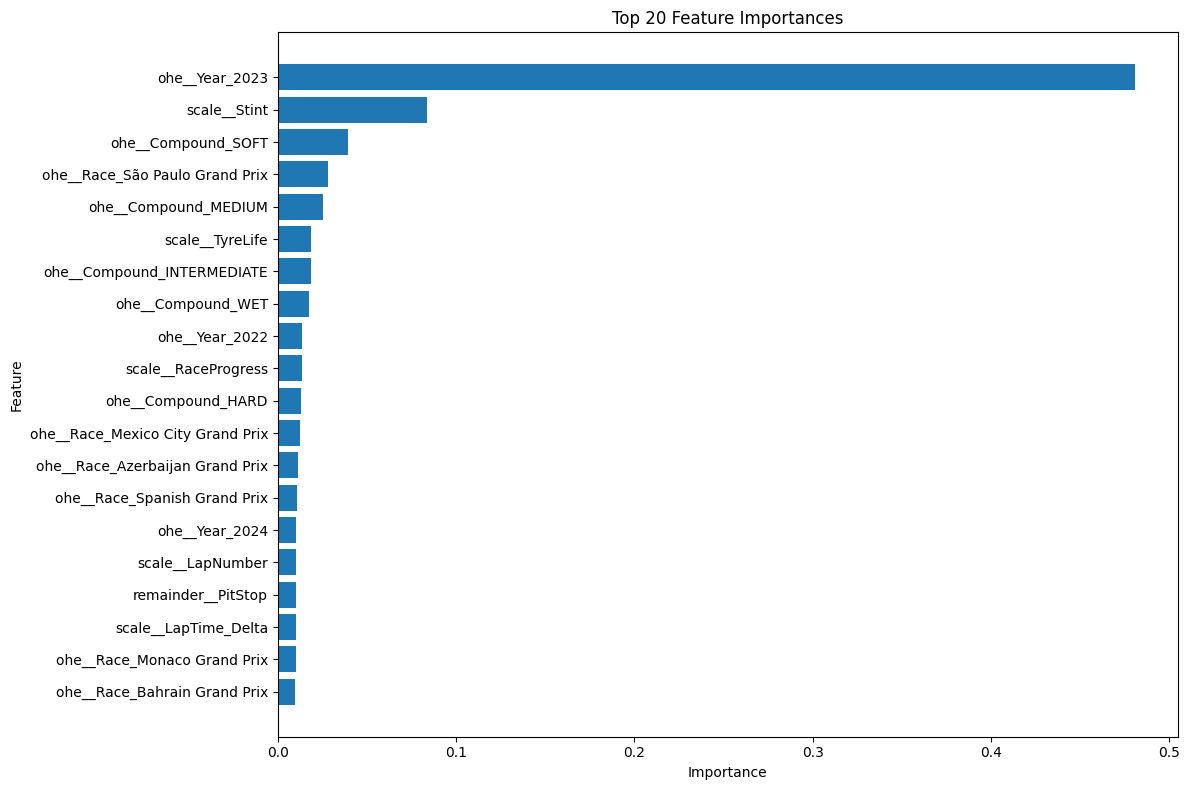

In [19]:
importance_df = pd.DataFrame({
    "Feature": X_train_transformed.columns,
    "Importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Top 20 feature
top_features = importance_df.head(20)

plt.figure(figsize=(12, 8))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances")

plt.tight_layout()
plt.show()

# 6. Submission

In [20]:
test_df = pd.read_csv("test.csv")
X_submission = preprocessor.transform(test_df)

X_submission = pd.DataFrame(
    X_submission,
    columns=preprocessor.get_feature_names_out(),
    index=test_df.index
)

submission_probs = best_model.predict_proba(X_submission)[:, 1]

submission = pd.DataFrame({
    "id": test_df["id"],
    "PitNextLap": submission_probs
})

submission.to_csv("submission_1.csv", index=False)
print("submission created")

submission created


# 7. CatBoost Model Building and Submission

In [21]:
# Target
y = df["PitNextLap"]

# Feature set
drop_cols = ["PitNextLap"]
X = df.drop(columns=drop_cols)

X_submission = test_df.drop(columns=["id"])

# Categorical columns
cat_features = [
    "Driver",
    "Compound",
    "Race",
    "Year"
]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_weight = neg / pos

print("scale_pos_weight:", scale_weight)

# CatBoost model
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=7,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    class_weights=[1, scale_weight],
    task_type="GPU",   # GPU varsa
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=100
)

# Validation prediction
y_probs = cat_model.predict_proba(X_valid)[:, 1]
y_pred = cat_model.predict(X_valid)

print("\n--- Validation Evaluation ---")
print(f"AUC Score: {roc_auc_score(y_valid, y_probs):.4f}")
print(f"Accuracy: {accuracy_score(y_valid, y_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_valid, y_pred))
print("\nClassification Report:\n", classification_report(y_valid, y_pred))

scale_pos_weight: 4.025563264430298


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9085414	best: 0.9085414 (0)	total: 79.5ms	remaining: 1m 19s
100:	test: 0.9367520	best: 0.9367520 (100)	total: 5.18s	remaining: 46.1s
200:	test: 0.9410264	best: 0.9410264 (200)	total: 9.24s	remaining: 36.7s
300:	test: 0.9434016	best: 0.9434016 (300)	total: 13.8s	remaining: 32s
400:	test: 0.9447731	best: 0.9447731 (400)	total: 19.6s	remaining: 29.3s
500:	test: 0.9458163	best: 0.9458163 (500)	total: 25.2s	remaining: 25.1s
600:	test: 0.9466043	best: 0.9466043 (600)	total: 30.9s	remaining: 20.5s
700:	test: 0.9471176	best: 0.9471176 (700)	total: 36s	remaining: 15.3s
800:	test: 0.9475312	best: 0.9475312 (800)	total: 40.5s	remaining: 10.1s
900:	test: 0.9478661	best: 0.9478661 (900)	total: 45.3s	remaining: 4.98s
999:	test: 0.9481728	best: 0.9481728 (999)	total: 49.3s	remaining: 0us
bestTest = 0.9481728077
bestIteration = 999

--- Validation Evaluation ---
AUC Score: 0.9482
Accuracy: 0.8679

Confusion Matrix:
 [[60302 10050]
 [ 1555 15921]]

Classification Report:
               preci

In [22]:
submission_probs = cat_model.predict_proba(X_submission)[:, 1]

submission = pd.DataFrame({
    "id": test_df["id"],
    "PitNextLap": submission_probs
})

submission.to_csv("catboost_submission.csv", index=False)
print("created")

created


# 8. Model with StratifiedKFold

In [38]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

test_df = pd.read_csv("test.csv")
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test_df))

auc_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]
    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    X_train_t = preprocessor.fit_transform(X_train)
    X_valid_t = preprocessor.transform(X_valid)
    X_test_t = preprocessor.transform(test_df.drop(columns=["id"], errors="ignore"))

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42 + fold,
        tree_method="hist",
        device="cuda",
        n_estimators=700,
        max_depth=7,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.6,
        min_child_weight=7,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=3,
        scale_pos_weight=5
    )

    model.fit(X_train_t, y_train)

    valid_probs = model.predict_proba(X_valid_t)[:, 1]
    oof_preds[valid_idx] = valid_probs

    auc = roc_auc_score(y_valid, valid_probs)
    auc_scores.append(auc)

    test_preds += model.predict_proba(X_test_t)[:, 1] / skf.n_splits

    print(f"Fold {fold+1} AUC: {auc:.5f}")

print("Mean AUC:", np.mean(auc_scores))
print("OOF AUC:", roc_auc_score(y, oof_preds))

Fold 1 AUC: 0.94983
Fold 2 AUC: 0.94804
Fold 3 AUC: 0.94879
Fold 4 AUC: 0.94809
Fold 5 AUC: 0.94889
Mean AUC: 0.9487274039591732
OOF AUC: 0.9487210418539127


In [40]:
X_test_final = preprocessor.transform(
    test_df.drop(columns=["id"], errors="ignore")
)

submission = pd.DataFrame({
    "id": test_df["id"],
    "PitNextLap": test_preds
})

# CSV
submission.to_csv("submission_fold.csv", index=False)

print("\nSubmission shape:", submission.shape)


Submission shape: (188165, 2)
